# 03_machine_learning_forecasting

UCI Individual Household Electric Power Consumption データを対象に、日次データへ集約したうえで、機械学習モデルによる時系列予測を行うノートブックです。

## 目的

- ラグ特徴量、移動統計量、カレンダー特徴量を作成する
- `LinearRegression`, `RandomForestRegressor`, `GradientBoostingRegressor`, `LightGBM` を比較する
- `LinearRegression` と `LightGBM` では、通常予測に加えて、トレンド除去後の系列を予測し、最後にトレンドを戻す方法も試す
- MAE / RMSE / MAPE で評価し、予測可視化と特徴量重要度を確認する

## 注意

このノートブックでは、時系列の順序を壊さないため、train/test split はシャッフルせず、前半80%を訓練、後半20%をテストにします。

## 1. ライブラリ読み込み

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from statsmodels.tsa.seasonal import seasonal_decompose

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("lightgbm がインストールされていないため、LightGBM のセルはスキップされます。")

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (12, 5)

## 2. データ読み込み

既存の前処理済みデータがあればそれを使い、見つからなければ元データ `household_power_consumption.txt` を読み込みます。

このデータは `;` 区切りで、欠損値が `?` として入っているため、読み込み時に `na_values="?"` を指定します。

In [2]:
DATA_CANDIDATES = [
    Path("household_power_consumption.txt"),
    Path("data/household_power_consumption.txt"),
    Path("../data/household_power_consumption.txt"),
    Path("/mnt/data/household_power_consumption.txt"),
]

TARGET_COL = "Global_active_power"
AGG_RULE = "D"  # 日次データを使用する


def find_existing_path(candidates):
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "household_power_consumption.txt が見つかりません。\n"
        "このノートブックと同じフォルダ、data/、../data/、または /mnt/data/ に配置してください。"
    )


def load_raw_household_power(path: Path, target_col: str = TARGET_COL) -> pd.DataFrame:
    # 予測対象に必要な列だけを読み込む。
    # 全列を読み込むより軽く、日次予測用ノートブックとして実行しやすい。
    df = pd.read_csv(
        path,
        sep=";",
        usecols=["Date", "Time", target_col],
        na_values="?",
        low_memory=False,
        memory_map=True,
    )
    df["datetime"] = pd.to_datetime(
        df["Date"] + " " + df["Time"],
        format="%d/%m/%Y %H:%M:%S",
        errors="coerce",
    )
    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
    df = df.drop(columns=["Date", "Time"])
    df = df.dropna(subset=["datetime"])
    df = df.set_index("datetime").sort_index()
    return df

raw_path = find_existing_path(DATA_CANDIDATES)
print("読み込みファイル:", raw_path)

raw = load_raw_household_power(raw_path)
print(raw.shape)
raw.head()

読み込みファイル: ..\data\household_power_consumption.txt
(2075259, 1)


,Global_active_power
datetime,
2006-12-16 17:24:00,4.216
2006-12-16 17:25:00,5.360
2006-12-16 17:26:00,5.374
2006-12-16 17:27:00,5.388
2006-12-16 17:28:00,3.666


## 3. 日次データへ集約

今回は日次データを使います。ここでは `Global_active_power` の日次平均を目的変数にします。

- 分単位データは細かすぎるため、まず日次へ集約する
- 欠損日は `asfreq("D")` で明示し、時間方向の補間で埋める

In [3]:
y_daily = raw[[TARGET_COL]].resample(AGG_RULE).mean()
y_daily = y_daily.asfreq(AGG_RULE)
y_daily[TARGET_COL] = y_daily[TARGET_COL].interpolate(method="time").ffill().bfill()

y_daily.info()
y_daily.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2006-12-16 to 2010-11-26
Freq: D
Data columns (total 1 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Global_active_power  1442 non-null   float64
dtypes: float64(1)
memory usage: 22.5 KB


,Global_active_power
datetime,
2006-12-16,3.053475
2006-12-17,2.354486
2006-12-18,1.530435
2006-12-19,1.157079
2006-12-20,1.545658


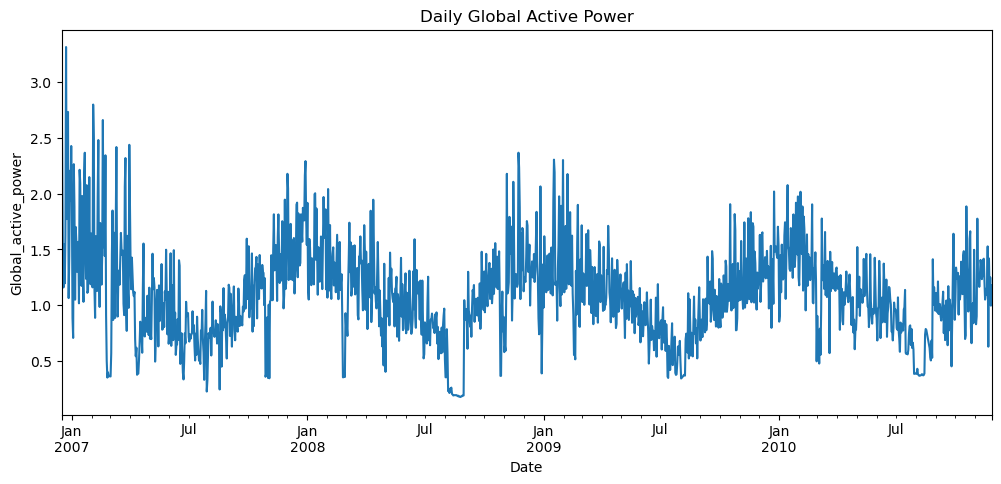

In [4]:
ax = y_daily[TARGET_COL].plot(title="Daily Global Active Power")
ax.set_xlabel("Date")
ax.set_ylabel(TARGET_COL)
plt.show()

## 4. ラグ特徴量・移動統計量・カレンダー特徴量

使う特徴量は設計通りです。

### ラグ特徴量

- `lag_1`
- `lag_7`
- `lag_14`
- `lag_30`

### 移動統計量特徴量

- `rolling_mean_7`, `rolling_std_7`
- `rolling_mean_14`, `rolling_std_14`
- `rolling_mean_30`, `rolling_std_30`

### カレンダー特徴量

- `dayofweek`
- `month`
- `is_weekend`

移動統計量は、当日の値を含めるとリークになるため、`shift(1)` してから計算します。

In [5]:
def make_features(y: pd.DataFrame, target_col: str = TARGET_COL) -> pd.DataFrame:
    df = y.copy()

    # ラグ特徴量
    for lag in [1, 7, 14, 30]:
        df[f"lag_{lag}"] = df[target_col].shift(lag)

    # 移動統計量特徴量: 当日を含めないため shift(1) してから rolling
    shifted = df[target_col].shift(1)
    for window in [7, 14, 30]:
        df[f"rolling_mean_{window}"] = shifted.rolling(window=window).mean()
        df[f"rolling_std_{window}"] = shifted.rolling(window=window).std()

    # カレンダー特徴量
    df["dayofweek"] = df.index.dayofweek
    df["month"] = df.index.month
    df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

    return df

feature_df = make_features(y_daily)
feature_df.head(35)

,Global_active_power,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30,dayofweek,month,is_weekend
datetime,,,,,,,,,,,,,,
2006-12-16,3.053475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,12,1
2006-12-17,2.354486,3.053475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,12,1
2006-12-18,1.530435,2.354486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,12,0
2006-12-19,1.157079,1.530435,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12,0
2006-12-20,1.545658,1.157079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,12,0
2006-12-21,1.193758,1.545658,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,12,0
2006-12-22,1.625929,1.193758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,12,0
2006-12-23,3.314851,1.625929,3.053475,NaN,NaN,1.780117,0.686102,NaN,NaN,NaN,NaN,5,12,1
2006-12-24,1.770842,3.314851,2.354486,NaN,NaN,1.817457,0.769050,NaN,NaN,NaN,NaN,6,12,1


In [6]:
# 特徴量作成で生じた欠損値を除去
model_df = feature_df.dropna().copy()

feature_cols = [c for c in model_df.columns if c != TARGET_COL]
X = model_df[feature_cols]
y = model_df[TARGET_COL]

print("model_df shape:", model_df.shape)
print("feature columns:", feature_cols)
model_df.head()

model_df shape: (1412, 14)
feature columns: ['lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30', 'rolling_std_30', 'dayofweek', 'month', 'is_weekend']


,Global_active_power,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30,dayofweek,month,is_weekend
datetime,,,,,,,,,,,,,,
2007-01-15,1.492137,2.090213,1.556500,1.909031,3.053475,1.605002,0.421003,1.544618,0.501632,1.762659,0.626866,0,1,0
2007-01-16,1.171114,1.492137,1.297954,0.881414,2.354486,1.595808,0.422937,1.514840,0.490588,1.710614,0.578988,1,1,0
2007-01-17,1.977561,1.171114,1.496389,0.704204,1.530435,1.577688,0.440191,1.535532,0.467376,1.671169,0.573898,2,1,0
2007-01-18,1.264904,1.977561,1.566107,2.263481,1.157079,1.646427,0.462389,1.626487,0.414004,1.686073,0.575919,3,1,0
2007-01-19,1.028083,1.264904,1.014789,1.884281,1.545658,1.603398,0.484591,1.555160,0.380480,1.689667,0.572832,4,1,0


## 5. train/test split と正規化データの作成

訓練データ : テストデータ = 8 : 2 とします。

- 通常データ: tree系モデル、LightGBMで使用
- 正規化データ: LinearRegressionで使用

時系列データなので、ランダム分割は使いません。

In [7]:
split_idx = int(len(model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns,
)

print("train:", X_train.shape, y_train.shape)
print("test :", X_test.shape, y_test.shape)
print("train period:", y_train.index.min(), "->", y_train.index.max())
print("test period :", y_test.index.min(), "->", y_test.index.max())

train: (1129, 13) (1129,)
test : (283, 13) (283,)
train period: 2007-01-15 00:00:00 -> 2010-02-16 00:00:00
test period : 2010-02-17 00:00:00 -> 2010-11-26 00:00:00


## 6. 評価関数

In [8]:
def evaluate_forecast(y_true, y_pred, model_name: str) -> dict:
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)

    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    }


def plot_prediction(y_train, y_test, pred_dict, title="Forecast comparison"):
    plt.figure(figsize=(14, 6))
    plt.plot(y_train.index, y_train, label="train", alpha=0.6)
    plt.plot(y_test.index, y_test, label="test", linewidth=2)

    for name, pred in pred_dict.items():
        plt.plot(y_test.index, pred, label=name, alpha=0.9)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.show()


results = []
predictions = {}
feature_importances = {}

## 7. 系列分解で構造を見る

ここではモデル学習そのものではなく、時系列の構造を確認するために分解を行います。

日次データなので、十分な長さがある場合は年周期 `period=365` を使います。データ長が不足する場合は週周期 `period=7` に切り替えます。

decompose_period: 365


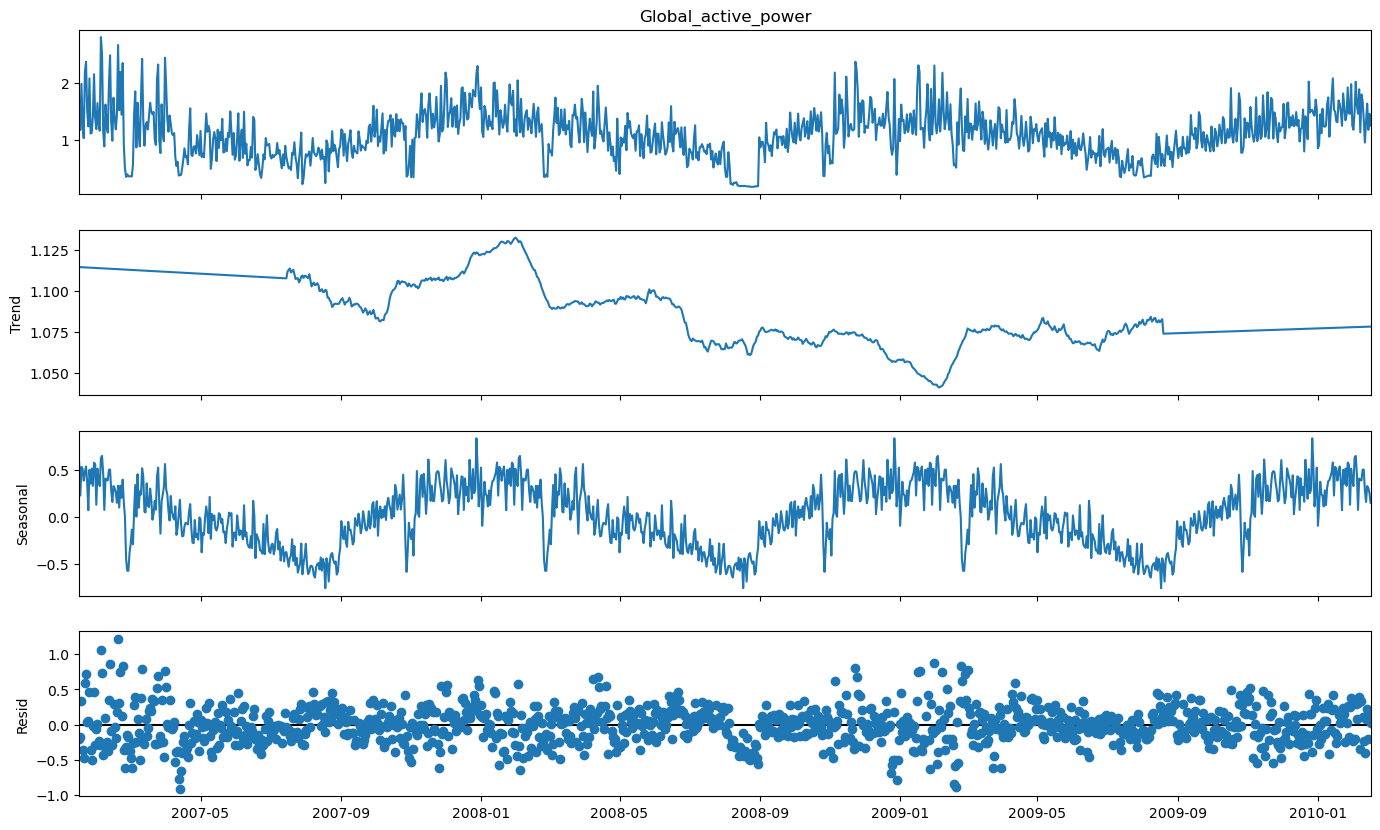

In [9]:
decompose_period = 365 if len(y_train) >= 365 * 2 else 7
print("decompose_period:", decompose_period)

decomp = seasonal_decompose(
    y_train,
    model="additive",
    period=decompose_period,
    extrapolate_trend="freq",
)

fig = decomp.plot()
fig.set_size_inches(14, 9)
plt.show()

## 8. トレンド除去用の補助関数

ここでは、訓練データだけから線形トレンドを推定します。

手順は次です。

1. 訓練期間の `y_train` から線形トレンドを推定する
2. `y_train - trend_train` を作る
3. 機械学習モデルで、トレンド除去後の値を予測する
4. テスト期間の将来トレンドを足し戻す

これにより、モデルはトレンドそのものではなく、トレンドからのズレを学習します。

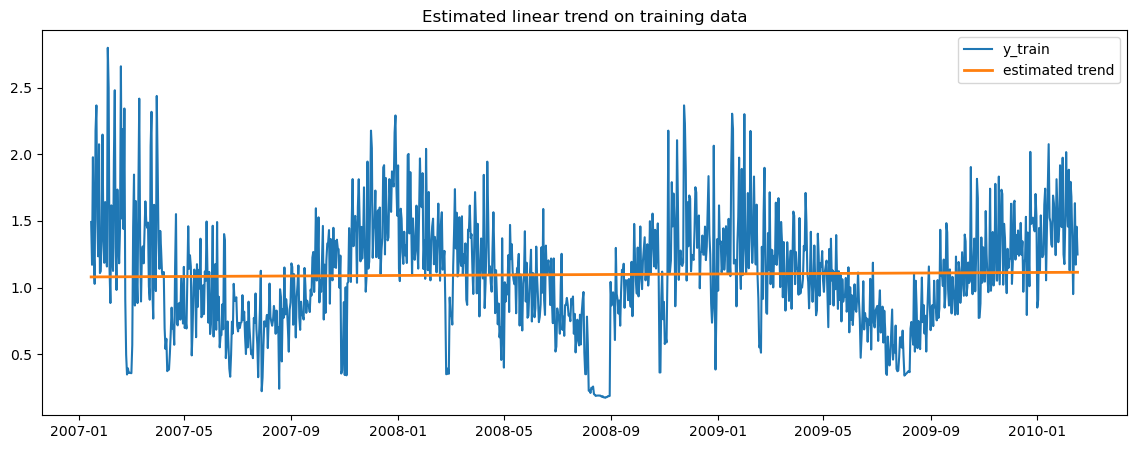

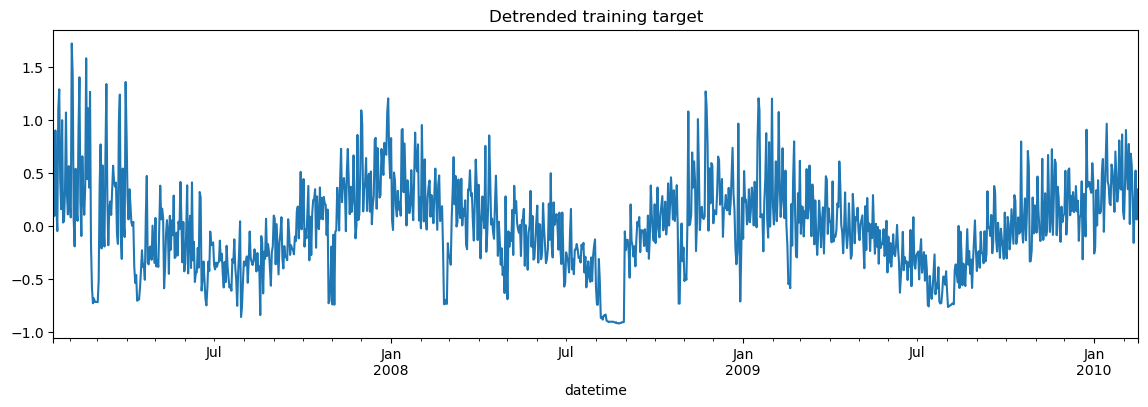

In [10]:
def fit_linear_trend(y_train: pd.Series, y_all_index: pd.Index):
    # 全期間に対して 0, 1, ..., n-1 の時刻番号を振る
    all_t = pd.Series(np.arange(len(y_all_index)), index=y_all_index, name="t")
    train_t = all_t.loc[y_train.index].to_numpy().reshape(-1, 1)

    trend_model = LinearRegression()
    trend_model.fit(train_t, y_train.values)

    trend_all = pd.Series(
        trend_model.predict(all_t.to_numpy().reshape(-1, 1)),
        index=y_all_index,
        name="linear_trend",
    )
    return trend_model, trend_all

trend_model, trend_all = fit_linear_trend(y_train, model_df.index)
trend_train = trend_all.loc[y_train.index]
trend_test = trend_all.loc[y_test.index]

y_train_detrended = y_train - trend_train

plt.figure(figsize=(14, 5))
plt.plot(y_train.index, y_train, label="y_train")
plt.plot(trend_train.index, trend_train, label="estimated trend", linewidth=2)
plt.title("Estimated linear trend on training data")
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
y_train_detrended.plot(title="Detrended training target")
plt.show()

## 9. LinearRegression

LinearRegression は特徴量スケールの影響を受けやすいため、正規化した特徴量を使います。

ここでは2種類を試します。

1. 通常の目的変数をそのまま予測
2. トレンド除去後の目的変数を予測し、最後にトレンドを戻す

In [11]:
# 9-1. 通常の LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = pd.Series(lr.predict(X_test_scaled), index=y_test.index, name="LinearRegression")
predictions["LinearRegression"] = pred_lr
results.append(evaluate_forecast(y_test, pred_lr, "LinearRegression"))

feature_importances["LinearRegression_coef_abs"] = pd.Series(
    np.abs(lr.coef_), index=feature_cols
).sort_values(ascending=False)

# 9-2. トレンド除去 LinearRegression
lr_detrended = LinearRegression()
lr_detrended.fit(X_train_scaled, y_train_detrended)

pred_lr_resid = pd.Series(
    lr_detrended.predict(X_test_scaled),
    index=y_test.index,
    name="LinearRegression_detrended_residual",
)

pred_lr_detrended = pred_lr_resid + trend_test
pred_lr_detrended.name = "LinearRegression_detrended"

predictions["LinearRegression_detrended"] = pred_lr_detrended
results.append(evaluate_forecast(y_test, pred_lr_detrended, "LinearRegression_detrended"))

feature_importances["LinearRegression_detrended_coef_abs"] = pd.Series(
    np.abs(lr_detrended.coef_), index=feature_cols
).sort_values(ascending=False)

pd.DataFrame(results)

,model,MAE,RMSE,MAPE
0,LinearRegression,0.182355,0.246311,0.211172
1,LinearRegression_detrended,0.185141,0.247649,0.219039


## 10. RandomForestRegressor

RandomForest は木ベースのモデルなので、基本的に正規化は不要です。

ここでは比較用として、通常の特徴量のみで予測します。

In [12]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

pred_rf = pd.Series(rf.predict(X_test), index=y_test.index, name="RandomForestRegressor")
predictions["RandomForestRegressor"] = pred_rf
results.append(evaluate_forecast(y_test, pred_rf, "RandomForestRegressor"))

feature_importances["RandomForestRegressor"] = pd.Series(
    rf.feature_importances_, index=feature_cols
).sort_values(ascending=False)

pd.DataFrame(results).sort_values("MAE")

,model,MAE,RMSE,MAPE
2,RandomForestRegressor,0.180173,0.245607,0.204136
0,LinearRegression,0.182355,0.246311,0.211172
1,LinearRegression_detrended,0.185141,0.247649,0.219039


## 11. GradientBoostingRegressor

GradientBoostingRegressor も木ベースのモデルなので、正規化なしの特徴量を使います。

ここでも比較用として、通常の特徴量のみで予測します。

In [13]:
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    random_state=42,
)
gbr.fit(X_train, y_train)

pred_gbr = pd.Series(gbr.predict(X_test), index=y_test.index, name="GradientBoostingRegressor")
predictions["GradientBoostingRegressor"] = pred_gbr
results.append(evaluate_forecast(y_test, pred_gbr, "GradientBoostingRegressor"))

feature_importances["GradientBoostingRegressor"] = pd.Series(
    gbr.feature_importances_, index=feature_cols
).sort_values(ascending=False)

pd.DataFrame(results).sort_values("MAE")

,model,MAE,RMSE,MAPE
3,GradientBoostingRegressor,0.167023,0.238333,0.184404
2,RandomForestRegressor,0.180173,0.245607,0.204136
0,LinearRegression,0.182355,0.246311,0.211172
1,LinearRegression_detrended,0.185141,0.247649,0.219039


## 12. LightGBM

LightGBM は木ベースの勾配ブースティングなので、正規化していない特徴量を使います。

ここでは2種類を試します。

1. 通常の目的変数をそのまま予測
2. トレンド除去後の目的変数を予測し、最後にトレンドを戻す

In [14]:
if LIGHTGBM_AVAILABLE:
    lgb_params = {
        "objective": "regression",
        "n_estimators": 500,
        "learning_rate": 0.03,
        "num_leaves": 15,
        "max_depth": -1,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "random_state": 42,
        "verbose": -1,
        "n_jobs": 1,
        "force_col_wise": True,
    }

    # 12-1. 通常の LightGBM
    lgbm = lgb.LGBMRegressor(**lgb_params)
    lgbm.fit(X_train, y_train)

    pred_lgbm = pd.Series(lgbm.predict(X_test), index=y_test.index, name="LightGBM")
    predictions["LightGBM"] = pred_lgbm
    results.append(evaluate_forecast(y_test, pred_lgbm, "LightGBM"))

    feature_importances["LightGBM"] = pd.Series(
        lgbm.feature_importances_, index=feature_cols
    ).sort_values(ascending=False)

    # 12-2. トレンド除去 LightGBM
    lgbm_detrended = lgb.LGBMRegressor(**lgb_params)
    lgbm_detrended.fit(X_train, y_train_detrended)

    pred_lgbm_resid = pd.Series(
        lgbm_detrended.predict(X_test),
        index=y_test.index,
        name="LightGBM_detrended_residual",
    )
    pred_lgbm_detrended = pred_lgbm_resid + trend_test
    pred_lgbm_detrended.name = "LightGBM_detrended"

    predictions["LightGBM_detrended"] = pred_lgbm_detrended
    results.append(evaluate_forecast(y_test, pred_lgbm_detrended, "LightGBM_detrended"))

    feature_importances["LightGBM_detrended"] = pd.Series(
        lgbm_detrended.feature_importances_, index=feature_cols
    ).sort_values(ascending=False)
else:
    print("LightGBM は未インストールです。次のコマンドでインストールできます。")
    print("conda install -c conda-forge lightgbm")

pd.DataFrame(results).sort_values("MAE")

,model,MAE,RMSE,MAPE
3,GradientBoostingRegressor,0.167023,0.238333,0.184404
5,LightGBM_detrended,0.177449,0.248498,0.200940
4,LightGBM,0.177627,0.249516,0.198671
2,RandomForestRegressor,0.180173,0.245607,0.204136
0,LinearRegression,0.182355,0.246311,0.211172
1,LinearRegression_detrended,0.185141,0.247649,0.219039


## 13. LightBGMのハイパーパラメータチューニング

## 14. 評価指標比較

MAE が小さいほど平均的な誤差が小さいです。RMSE は大きな誤差をより強く罰します。MAPE は相対誤差です。

In [15]:
results_df = pd.DataFrame(results).drop_duplicates(subset=["model"], keep="last")
results_df = results_df.sort_values("MAE").reset_index(drop=True)
results_df

,model,MAE,RMSE,MAPE
0,GradientBoostingRegressor,0.167023,0.238333,0.184404
1,LightGBM_detrended,0.177449,0.248498,0.200940
2,LightGBM,0.177627,0.249516,0.198671
3,RandomForestRegressor,0.180173,0.245607,0.204136
4,LinearRegression,0.182355,0.246311,0.211172
5,LinearRegression_detrended,0.185141,0.247649,0.219039


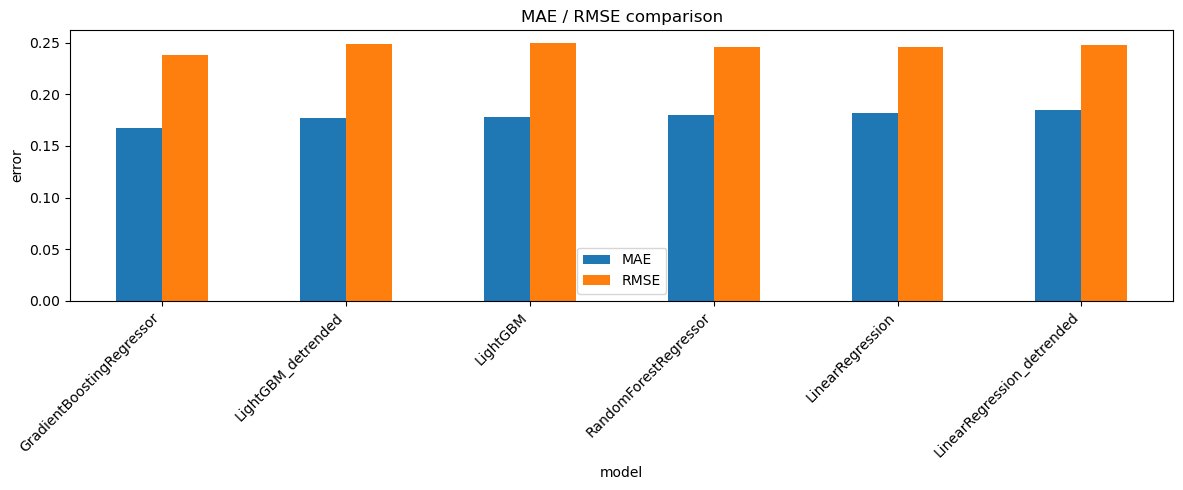

In [16]:
ax = results_df.set_index("model")[["MAE", "RMSE"]].plot(kind="bar", figsize=(12, 5))
ax.set_title("MAE / RMSE comparison")
ax.set_ylabel("error")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 15. 予測可視化

全モデルの予測を比較します。線が重なって見にくい場合は、下のセルで表示モデルを絞ってください。

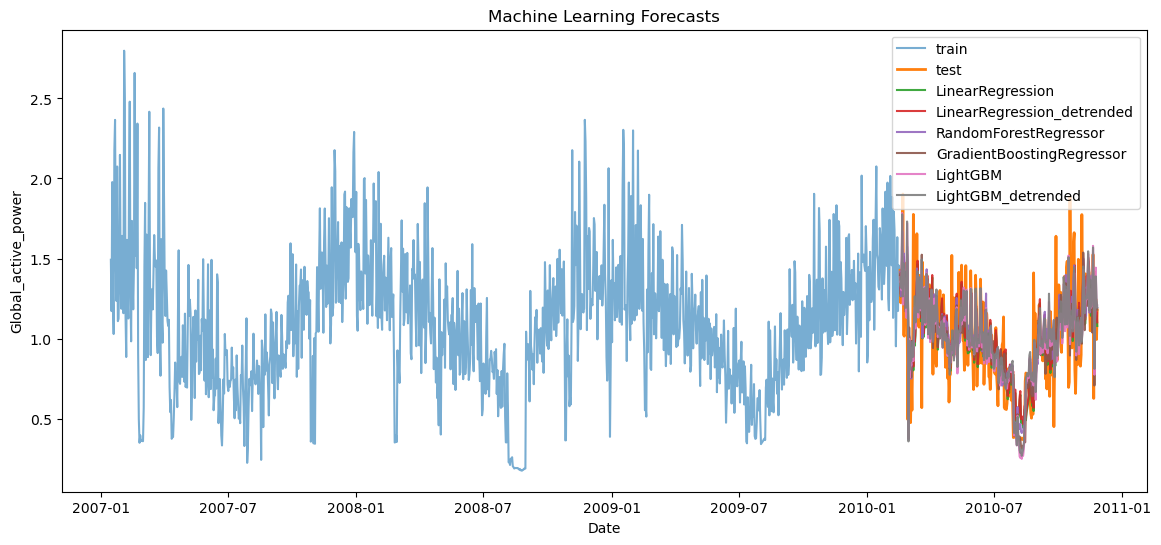

In [17]:
plot_prediction(y_train, y_test, predictions, title="Machine Learning Forecasts")

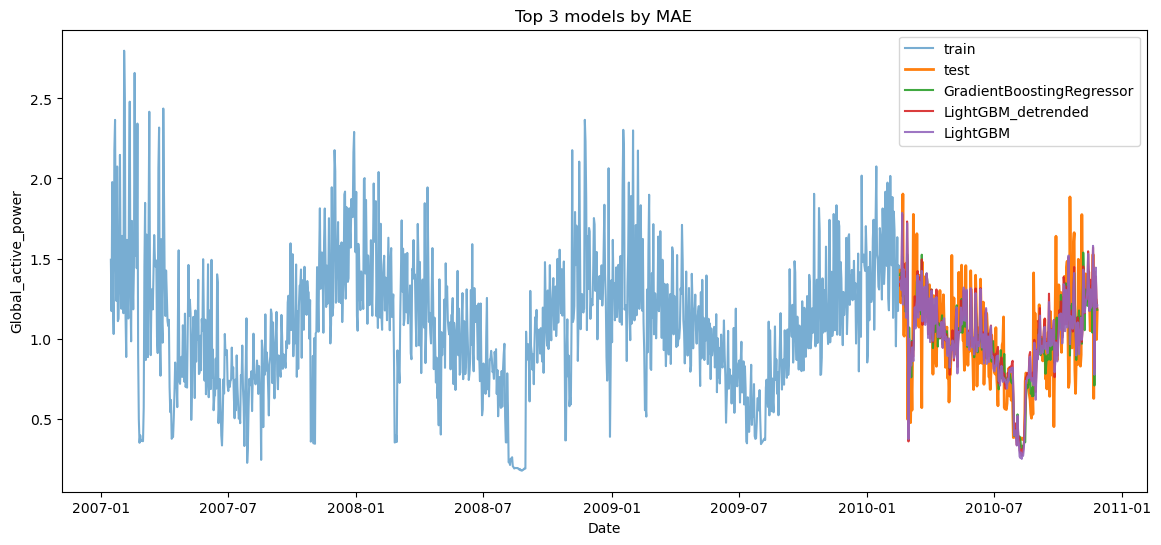

In [18]:
# 見やすくするため、上位モデルだけを表示
best_model_names = results_df["model"].head(3).tolist()
best_predictions = {name: predictions[name] for name in best_model_names if name in predictions}

plot_prediction(y_train, y_test, best_predictions, title="Top 3 models by MAE")

## 16. 特徴量重要度

線形回帰では係数の絶対値、木ベースモデルでは `feature_importances_` を確認します。

ただし、モデル間で重要度の定義は異なるため、絶対値をそのまま横比較するのではなく、各モデル内で「どの特徴量を重視しているか」を見るために使います。

,importance
feature,
rolling_mean_7,0.251141
rolling_mean_14,0.133792
lag_1,0.089324
lag_14,0.070855
is_weekend,0.053851
rolling_mean_30,0.052703
rolling_std_7,0.050022
rolling_std_30,0.029348
lag_7,0.027829


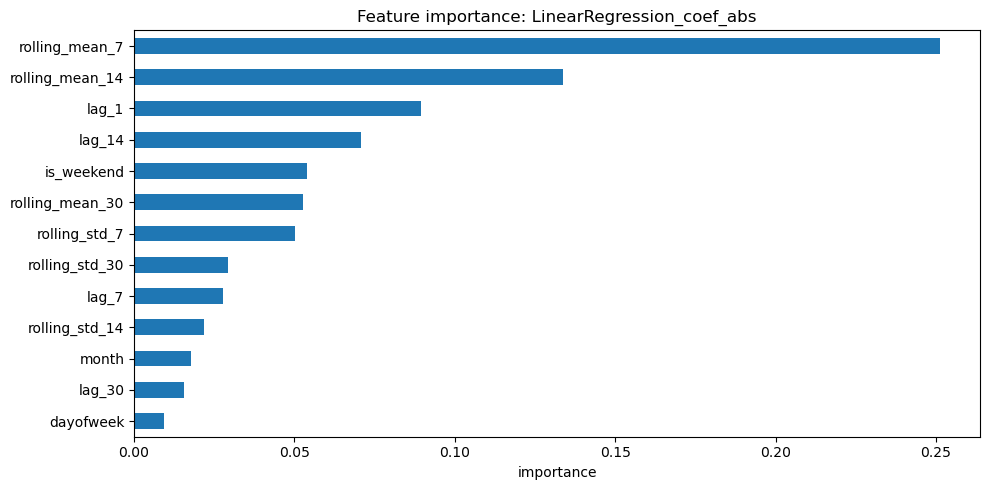

,importance
feature,
rolling_mean_7,0.250369
rolling_mean_14,0.134276
lag_1,0.088833
lag_14,0.070808
is_weekend,0.053852
rolling_mean_30,0.051397
rolling_std_7,0.049231
rolling_std_30,0.034343
lag_7,0.027889


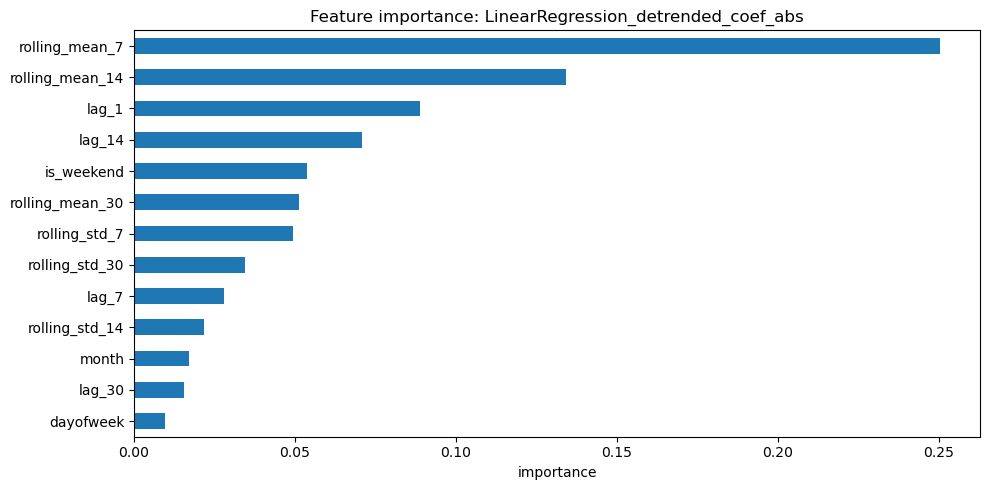

,importance
feature,
rolling_mean_7,0.389673
lag_1,0.162746
lag_14,0.068964
rolling_mean_14,0.065043
lag_7,0.054931
rolling_std_30,0.044723
rolling_std_14,0.039060
rolling_mean_30,0.037600
dayofweek,0.035817


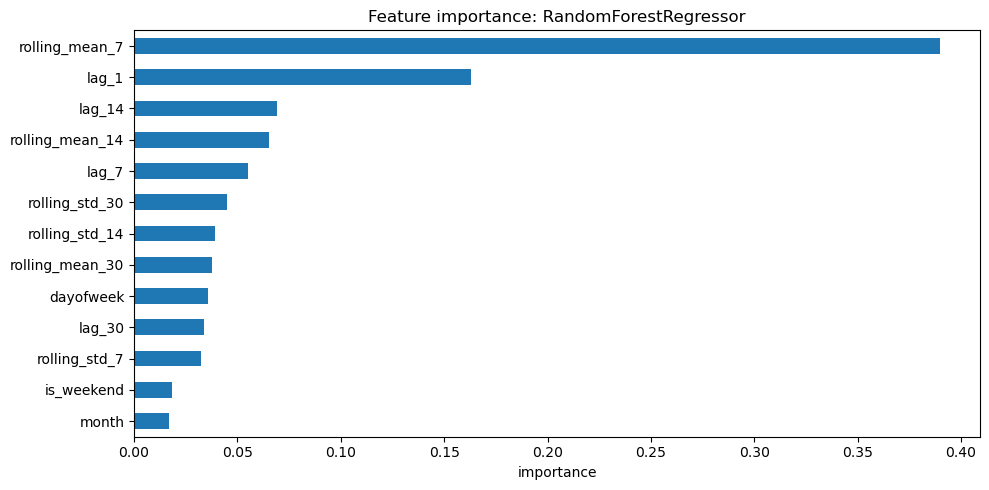

,importance
feature,
rolling_mean_7,0.379160
lag_1,0.241324
lag_14,0.065251
rolling_mean_14,0.050274
lag_7,0.042729
rolling_std_30,0.039363
dayofweek,0.038173
rolling_mean_30,0.038124
rolling_std_14,0.027476


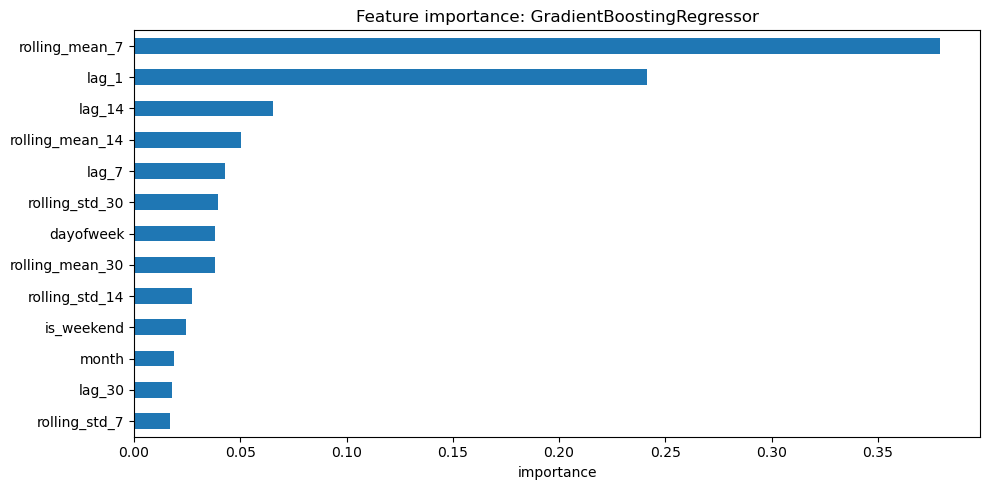

,importance
feature,
rolling_std_14,774
lag_1,747
rolling_std_7,642
rolling_mean_30,642
rolling_mean_7,637
lag_14,635
lag_7,634
rolling_std_30,607
rolling_mean_14,606


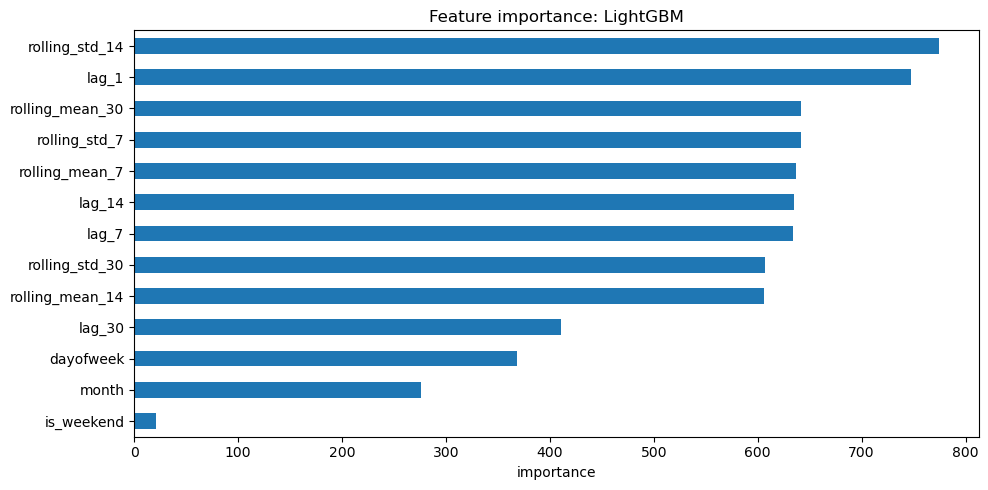

,importance
feature,
lag_1,799
rolling_std_30,696
rolling_std_14,692
lag_7,661
rolling_mean_30,639
rolling_std_7,639
rolling_mean_7,609
lag_14,608
rolling_mean_14,589


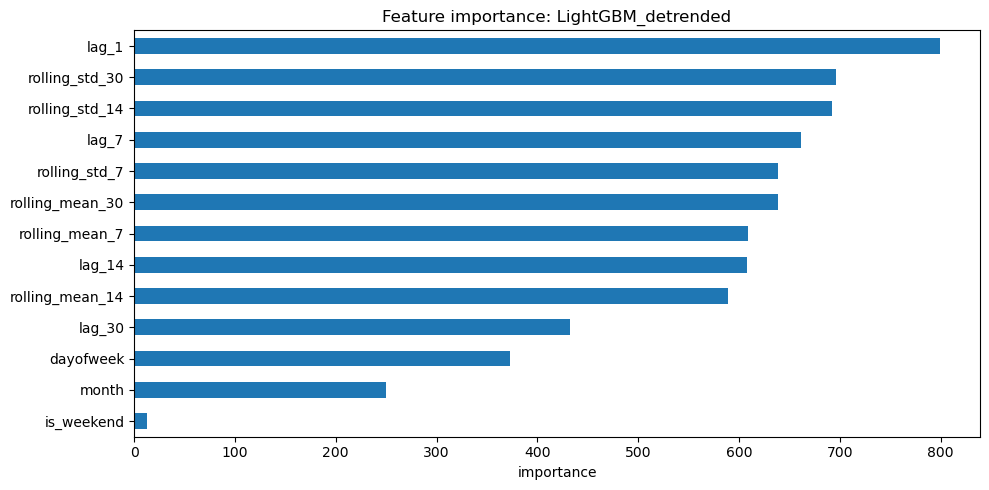

In [19]:
for name, importance in feature_importances.items():
    display(pd.DataFrame({"importance": importance}).head(15).rename_axis("feature"))

    ax = importance.head(15).sort_values().plot(kind="barh", figsize=(10, 5))
    ax.set_title(f"Feature importance: {name}")
    ax.set_xlabel("importance")
    plt.tight_layout()
    plt.show()

## 17. 予測結果の保存

評価結果と予測値をCSVで保存します。

In [20]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

results_df.to_csv(output_dir / "03_ml_forecasting_metrics.csv", index=False, encoding="utf-8-sig")

pred_df = pd.DataFrame({"y_true": y_test})
for name, pred in predictions.items():
    pred_df[name] = pred
pred_df.to_csv(output_dir / "03_ml_forecasting_predictions.csv", encoding="utf-8-sig")

print("saved:")
print(output_dir / "03_ml_forecasting_metrics.csv")
print(output_dir / "03_ml_forecasting_predictions.csv")
pred_df.head()

saved:
outputs\03_ml_forecasting_metrics.csv
outputs\03_ml_forecasting_predictions.csv


,y_true,LinearRegression,LinearRegression_detrended,RandomForestRegressor,GradientBoostingRegressor,LightGBM,LightGBM_detrended
datetime,,,,,,,
2010-02-17,1.426778,1.310940,1.324443,1.417181,1.395716,1.353934,1.330580
2010-02-18,1.223025,1.262807,1.276253,1.264171,1.409999,1.361699,1.383052
2010-02-19,1.356647,1.287581,1.301151,1.320272,1.348387,1.302179,1.313682
2010-02-20,1.377589,1.543639,1.557099,1.669928,1.510965,1.784943,1.775737
2010-02-21,1.902996,1.405156,1.418508,1.308685,1.260001,1.211635,1.263501


### 特徴量データの保存

In [21]:
data_03_dir = Path("data/03_data")
data_03_dir.mkdir(exist_ok=True)

model_df.to_csv(data_03_dir / "03_features_data.csv", encoding="utf-8-sig")

print("saved :")
print(data_03_dir /"03_features_data.csv")

saved :
data\03_data\03_features_data.csv


## 17. 考察メモ

このノートブックを実行したあと、以下を確認してください。

1. 通常の特徴量だけで強いモデルはどれか
2. LinearRegression でトレンド除去が有効だったか
3. LightGBM でトレンド除去が有効だったか
4. `lag_1`, `lag_7`, `rolling_mean_7`, `rolling_mean_30` のどれが効いているか
5. 予測がテスト期間の急変に追従できているか

次の改善候補は以下です。

- `lag_365` を追加して年周期を入れる
- 祝日特徴量を追加する
- 時間単位データで `lag_24`, `lag_168` を使う
- `TimeSeriesSplit` または `ExpandingWindowSplitter` による時系列CVを導入する
- TDA特徴量を追加して、通常特徴量との差分を検証する